In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import metrics
import numpy as np
from sklearn.linear_model import LinearRegression

data = pd.read_csv("./BostonHousing.csv")
data.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='str')

In [ ]:
x = data.iloc[:,:13]  #前13列（0-12，不包括13）是特征值
y = data.iloc[:,13:]  # 最后一列是目标值
# x.columns
y.head()

,medv
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2


In [11]:
x.shape

(506, 13)

In [12]:
# 查看数据表前5条
x.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


In [13]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


In [19]:
# x.describe()
# x.isnull().sum()
# rm一列有空值，需要用中位数来填充空值
x = x.fillna(x.median())
x.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
dtype: int64

In [20]:
# 划分数据集
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=3)


In [21]:
# 创建并且训练模型
model=LinearRegression()
model.fit(xtrain,ytrain)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 13)","[[-0.12, 0.05,-0.05,...,-0.91, 0.01,-0.48]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['crim','zn','indus',...,'ptratio','b','lstat']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[35.89]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13


In [22]:
# 模型评估
# 查看截距
model.intercept_

array([35.8878381])

In [ ]:
# 查看斜率,斜率为正的,就是对房价有帮助的特征
model.coef_

array([[-1.23967792e-01,  4.82184076e-02, -4.58601328e-02,
         3.37113105e+00, -1.56140148e+01,  3.57744597e+00,
        -8.92409620e-03, -1.45742446e+00,  3.06872368e-01,
        -1.09425181e-02, -9.09311371e-01,  1.00448052e-02,
        -4.78501228e-01]])

In [ ]:

# # 模型预测
ypred = model.predict(xtest)
# ytest.shape #(102, 1)
# type(ytest)
# type(ypred) #(102, 1)
# ypred.shape # 
# 模型效果评估
result_df = pd.DataFrame({"Actual":ytest.to_numpy().flatten(),"Predicted":ypred.flatten()})
print(result_df)
result_df.to_excel("线性回归波士顿房价预测效果.xlsx") # 把模型的预测结果保持起来

     Actual  Predicted
0      44.8  37.509358
1      17.1  18.757230
2      17.8  22.364310
3      33.1  32.795126
4      21.9  24.329313
..      ...        ...
97     11.7  15.783546
98     21.7  24.042081
99     33.4  35.264529
100    20.2  22.359049
101    19.4  23.650273

[102 rows x 2 columns]


<Axes: >

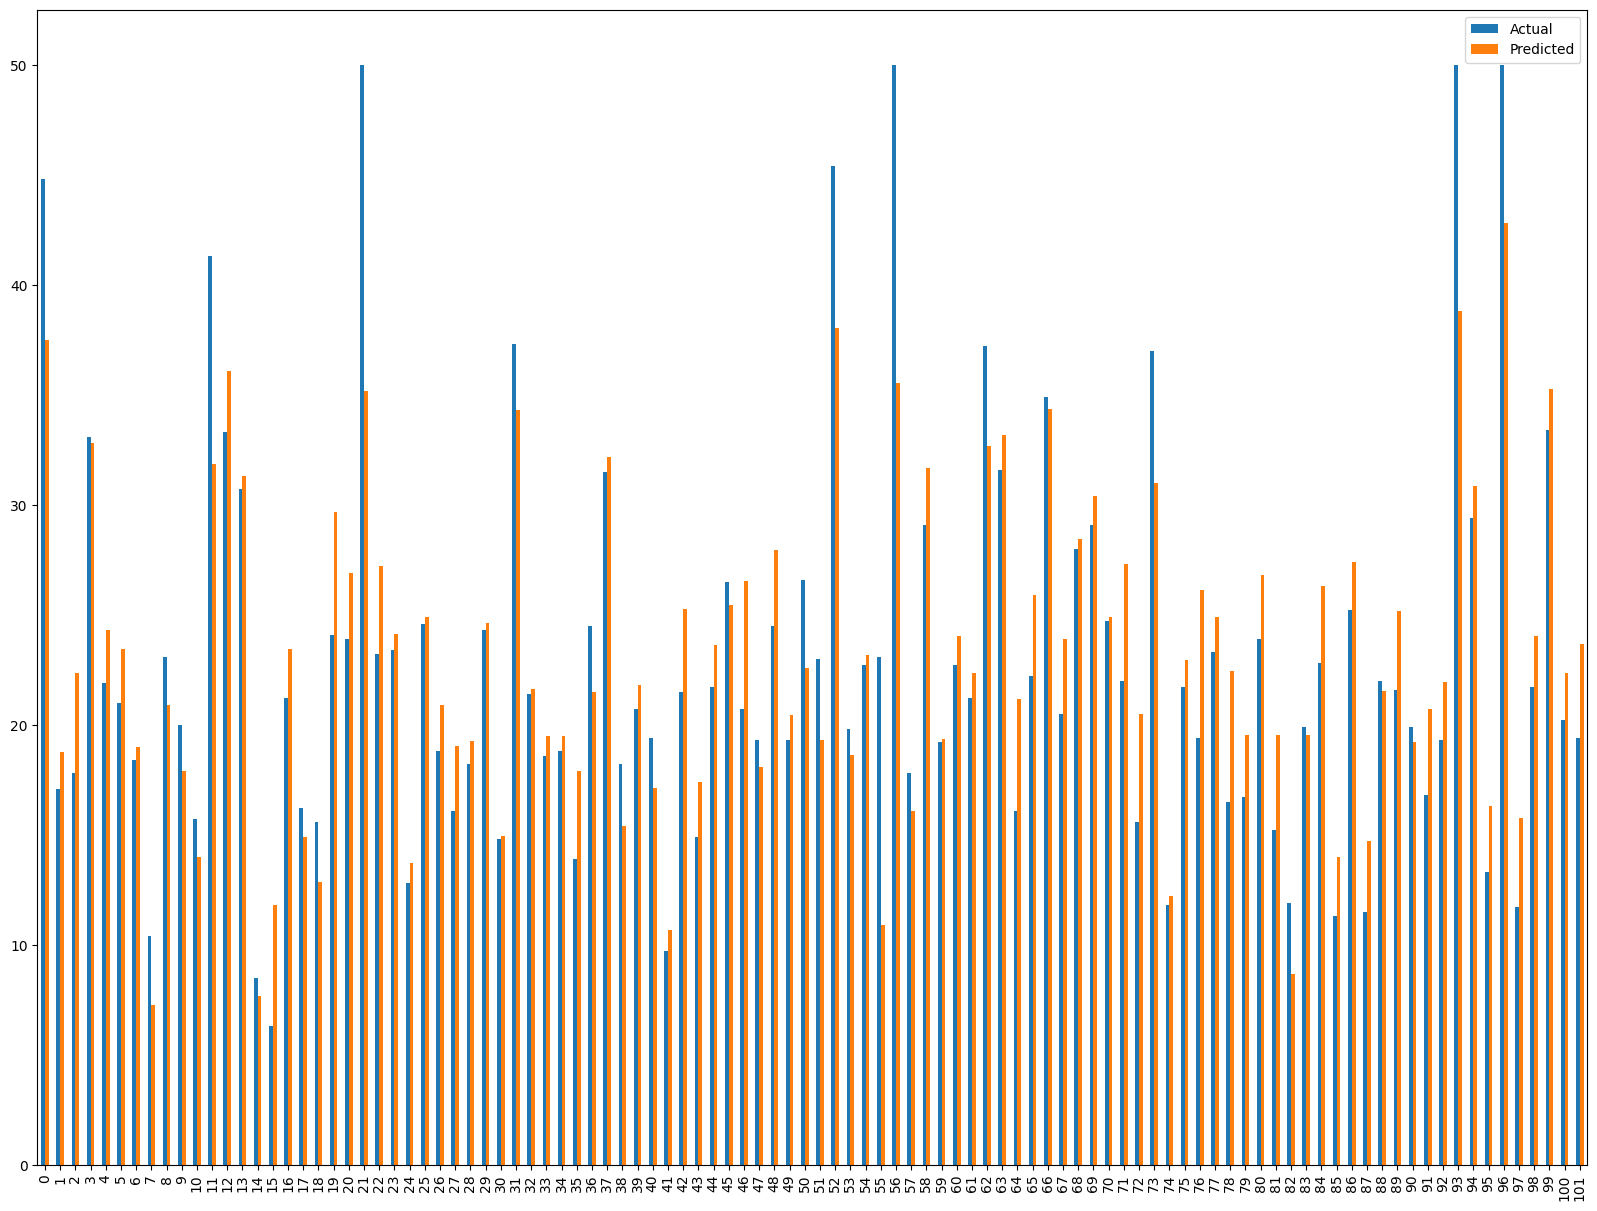

In [36]:
# 可视化
result_df.plot(kind='bar',figsize=(20,15))

In [ ]:
# 效果评估，
print('MeanAbsolute Error:', metrics.mean_absolute_error(ytest,ypred)) #MAE ,平均决定误差
print('MeanSquared Error:' ,metrics.mean_squared_error(ytest,ypred))  #MSE  ,均方误差
print('RootMeanSquared Error:', metrics.root_mean_squared_error(ytest,ypred)) #RMSE ,均方根误差

MeanAbsolute Error: 3.0166009536924383
MeanSquared Error: 16.96869059697039
RootMeanSquared Error: 4.119307053009084
